# NU Industries Production Planning Optimization

### Group Members

Samin Bahizad  
Bobby Hendricks  
Deysi Paniagua-Perez  
Nathan Stark  

## Project Summary

NU Industries manufactures Widgets, Gadgets, and Flugels at two plants over five production periods. The purpose of this project is to determine the production, inventory, advertising, labor, raw material, and shipping plan that maximizes total profit while meeting demand and staying within the company’s operating limits.

The baseline model includes regular and overtime labor, two raw materials, inventory held at each plant, advertising that increases demand in the following period, and shipments from each plant to the distribution center. After the baseline solution is reviewed, the group plans to complete sensitivity analysis, test changes to the advertising budget and raw material availability, and compare the linear programming solution with an integer programming model.

## Project Details

> **Hint:** This problem can be completed with fewer than 150 variables and fewer than 110 constraints.

## Problem Description

NU Industries operates two manufacturing plants that produce three products: Widgets, Gadgets, and Flugels. The finished products are shipped to the Distribution Center for final distribution to customers. Five production periods are to be scheduled.

According to the Sales Department, the production requirements that must be met due to contracts during the planning horizon are:

| Product | Period 1 | Period 2 | Period 3 | Period 4 | Period 5 |
|---|---:|---:|---:|---:|---:|
| Widgets | 70 | 125 | 185 | 190 | 200 |
| Gadgets | 200 | 300 | 295 | 245 | 240 |
| Flugels | 140 | 175 | 205 | 235 | 230 |

The Marketing and Forecasting Department anticipates that NU Industries can create additional demand through advertising.

- Each $160 invested in Widget advertising during one period creates demand for one additional Widget in the next period.
- Each $120 invested in Gadget advertising creates demand for one additional Gadget in the next period.
- Each $180 invested in Flugel advertising creates demand for one additional Flugel in the next period.
- The total advertising budget is limited to $70,000 for the entire planning horizon.

Throughout the planning horizon, NU Industries will sell:

| Product | Selling Price |
|---|---:|
| Widget | $2,490 |
| Gadget | $1,990 |
| Flugel | $2,970 |

The products can be manufactured at either Plant A or Plant B.

## Plant A

The production requirements at Plant A are:

- Each Widget requires 194 pounds of Raw Material 1, 8.6 pounds of Raw Material 2, and 9.5 hours of labor.
- Each Gadget requires 230 pounds of Raw Material 1 and 7.1 hours of labor.
- Each Flugel requires 178 pounds of Raw Material 1, 11.6 pounds of Raw Material 2, and 11.1 hours of labor.

Regular labor availability is limited to 2,500 hours in each period, but overtime can be scheduled in any amount if necessary.

Labor costs during periods 1 and 2 are:

- Regular labor: $11.00 per hour
- Overtime labor: $16.50 per hour

Labor costs increase by 5% after period 2.

The inventory area at Plant A can store a combined maximum of 70 units.

| Product | Inventory Cost per Unit |
|---|---:|
| Widget | $7.50 |
| Gadget | $5.50 |
| Flugel | $6.50 |

## Plant B

Plant B is the more modern facility and can produce the products slightly more efficiently.

The production requirements at Plant B are:

- Each Widget requires 188 pounds of Raw Material 1, 9.2 pounds of Raw Material 2, and 9.1 hours of labor.
- Each Gadget requires 225 pounds of Raw Material 1 and 7.8 hours of labor.
- Each Flugel requires 170 pounds of Raw Material 1, 10.8 pounds of Raw Material 2, and 10.6 hours of labor.

Regular labor availability is limited to 3,800 hours in each period, but overtime can be scheduled in any amount if necessary.

Labor costs during periods 1 and 2 are:

- Regular labor: $11.00 per hour
- Overtime labor: $16.50 per hour

Labor costs increase by 10% after period 2.

The inventory area at Plant B can store a combined maximum of 50 units.

| Product | Inventory Cost per Unit |
|---------|-----------------------:|
| Widget |         $7.80 |
| Gadget |         $5.70 |
| Flugel |         $7.00 |

## Raw Materials

A maximum of 70 tons of Raw Material 1 and 2.5 tons of Raw Material 2 are available from the vendor during each period.

Note: 1 ton = 2,000 pounds.

| Raw Material | Plant A Cost per Pound | Plant B Cost per Pound |
|---|---:|---:|
| Raw Material 1 | $1.25 | $1.45 |
| Raw Material 2 | $2.65 | $2.90 |

Each plant only purchases raw materials that can be used during the current period because storage space is limited.

## Transportation Costs

The average transportation cost for shipping one unit of finished product from each plant to the Distribution Center is:

| Product | Plant A | Plant B |
|---|---:|---:|
| Widget | $6.30 | $6.50 |
| Gadget | $4.60 | $5.00 |
| Flugel | $5.50 | $5.70 |

## Model Requirements

Demand during a given period must be satisfied using products manufactured during that period or inventory carried over from a previous period.

The goal is to determine the marketing, production, distribution, and inventory strategy that maximizes total profit.

The following assumptions apply:

- There is no inventory at the beginning of period 1.
- There should be no inventory at the end of period 5.
- All other plant overhead is constant and can be ignored.
- Fractional units are allowed in the baseline linear programming model.
- Results may be rounded to the nearest tenth for reporting purposes.

## Additional Analysis

After solving the baseline case, the group will complete a sensitivity analysis and make business recommendations.

The analysis should consider questions such as:

- Should the advertising budget be increased?
- If so, by how much?
- Which raw material is most limiting?
- How would additional raw material availability affect profit?
- How do the recommendations change under different scenarios?

The group will also solve the model as an integer programming problem and compare the results with the baseline linear programming solution.

In [1]:
%pip install pulp pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# import pulp and pandas
from pulp import LpVariable, LpProblem, LpMaximize, LpStatus, value, lpSum, GLPK
import pandas as pd
import matplotlib.pyplot as plt


## Model variables

In [3]:
# define variable
products = ["Widget", "Gadget", "Flugel"]
plants = ["Plant_A", "Plant_B"]
periods = [1, 2, 3, 4, 5]
advertising_periods = [1, 2, 3, 4]

## Case Study Data

In [4]:

# required contract demand by product and period
base_demand = {
    ("Widget", 1): 70,
    ("Widget", 2): 125,
    ("Widget", 3): 185,
    ("Widget", 4): 190,
    ("Widget", 5): 200,

    ("Gadget", 1): 200,
    ("Gadget", 2): 300,
    ("Gadget", 3): 295,
    ("Gadget", 4): 245,
    ("Gadget", 5): 240,

    ("Flugel", 1): 140,
    ("Flugel", 2): 175,
    ("Flugel", 3): 205,
    ("Flugel", 4): 235,
    ("Flugel", 5): 230
}

# selling price per unit
selling_price = {
    "Widget": 2490,
    "Gadget": 1990,
    "Flugel": 2970
}

# advertising cost required to create one additional unit of demand
advertising_cost = {
    "Widget": 160,
    "Gadget": 120,
    "Flugel": 180
}

# raw material 1 requirements in pounds per unit
raw_material_1 = {
    ("Plant_A", "Widget"): 194,
    ("Plant_A", "Gadget"): 230,
    ("Plant_A", "Flugel"): 178,

    ("Plant_B", "Widget"): 188,
    ("Plant_B", "Gadget"): 225,
    ("Plant_B", "Flugel"): 170
}

# raw material 2 requirements in pounds per unit - Gadgets do not require raw material 2.
raw_material_2 = {
    ("Plant_A", "Widget"): 8.6,
    ("Plant_A", "Gadget"): 0,
    ("Plant_A", "Flugel"): 11.6,

    ("Plant_B", "Widget"): 9.2,
    ("Plant_B", "Gadget"): 0,
    ("Plant_B", "Flugel"): 10.8
}

# labor requirements in hours per unit
labor_hours = {
    ("Plant_A", "Widget"): 9.5,
    ("Plant_A", "Gadget"): 7.1,
    ("Plant_A", "Flugel"): 11.1,

    ("Plant_B", "Widget"): 9.1,
    ("Plant_B", "Gadget"): 7.8,
    ("Plant_B", "Flugel"): 10.6
}

# regular labor availability by plant and period
regular_labor_capacity = {
    ("Plant_A", period): 2500 for period in periods
}
regular_labor_capacity.update({
    ("Plant_B", period): 3800 for period in periods
})

# regular labor cost per hour
regular_labor_cost = {
    ("Plant_A", period): 11 if period <= 2 else 11 * 1.05
    for period in periods
}
regular_labor_cost.update({
    ("Plant_B", period): 11 if period <= 2 else 11 * 1.10
    for period in periods
})

# overtime labor cost per hour
overtime_labor_cost = {
    ("Plant_A", period): 16.50 if period <= 2 else 16.50 * 1.05
    for period in periods
}
overtime_labor_cost.update({
    ("Plant_B", period): 16.50 if period <= 2 else 16.50 * 1.10
    for period in periods
})

# inventory capacity by plant
inventory_capacity = {
    "Plant_A": 70,
    "Plant_B": 50
}

# inventory cost for holding one unit from one period to the next
inventory_cost = {
    ("Plant_A", "Widget"): 7.50,
    ("Plant_A", "Gadget"): 5.50,
    ("Plant_A", "Flugel"): 6.50,

    ("Plant_B", "Widget"): 7.80,
    ("Plant_B", "Gadget"): 5.70,
    ("Plant_B", "Flugel"): 7.00
}

# raw material costs by plant
raw_material_1_cost = {
    "Plant_A": 1.25,
    "Plant_B": 1.45
}

raw_material_2_cost = {
    "Plant_A": 2.65,
    "Plant_B": 2.90
}

# transportation cost per unit shipped from a plant to the distribution center
shipping_cost = {
    ("Plant_A", "Widget"): 6.30,
    ("Plant_A", "Gadget"): 4.60,
    ("Plant_A", "Flugel"): 5.50,

    ("Plant_B", "Widget"): 6.50,
    ("Plant_B", "Gadget"): 5.00,
    ("Plant_B", "Flugel"): 5.70
}

# total limits that apply during each period
raw_material_1_capacity = 70 * 2000     # 70 tons converted to pounds
raw_material_2_capacity = 2.5 * 2000    # 2.5 tons converted to pounds
total_advertising_budget = 70000


## Decision Variables

In [5]:
# define production variables
production = {
    (product, plant, period): LpVariable(
        f"Production_{product}_{plant}_P{period}", 0, None
    )
    for product in products
    for plant in plants
    for period in periods
}

# define shipment variables
shipment = {
    (product, plant, period): LpVariable(
        f"Shipment_{product}_{plant}_P{period}", 0, None
    )
    for product in products
    for plant in plants
    for period in periods
}

# define inventory variables
inventory = {
    (product, plant, period): LpVariable(
        f"Inventory_{product}_{plant}_P{period}", 0, None
    )
    for product in products
    for plant in plants
    for period in periods
}

# define regular labor variables
regular_labor = {
    (plant, period): LpVariable(
        f"Regular_Labor_{plant}_P{period}",
        0,
        regular_labor_capacity[(plant, period)]
    )
    for plant in plants
    for period in periods
}

# define overtime labor variables
overtime_labor = {
    (plant, period): LpVariable(
        f"Overtime_Labor_{plant}_P{period}", 0, None
    )
    for plant in plants
    for period in periods
}

# define advertising variables
advertising = {
    (product, period): LpVariable(
        f"Advertising_Demand_{product}_P{period}", 0, None
    )
    for product in products
    for period in advertising_periods
}

## Optimization Problem and Objective Function

In [6]:
# defines the problem
nu_model = LpProblem("NU_Industries_Baseline", LpMaximize)

# calculate total sales revenue
total_revenue = lpSum(
    selling_price[product] * shipment[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

# calculate total raw material cost
total_raw_material_cost = lpSum(
    (
        raw_material_1[(plant, product)] * raw_material_1_cost[plant]
        + raw_material_2[(plant, product)] * raw_material_2_cost[plant]
    ) * production[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

# calculate total regular labor cost
total_regular_labor_cost = lpSum(
    regular_labor_cost[(plant, period)] * regular_labor[(plant, period)]
    for plant in plants
    for period in periods
)

# calculate total overtime labor cost
total_overtime_labor_cost = lpSum(
    overtime_labor_cost[(plant, period)] * overtime_labor[(plant, period)]
    for plant in plants
    for period in periods
)

# calculate total inventory cost
total_inventory_cost = lpSum(
    inventory_cost[(plant, product)] * inventory[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods[:-1]
)

# calculate total transportation cost
total_shipping_cost = lpSum(
    shipping_cost[(plant, product)] * shipment[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

# calculate total advertising cost
total_advertising_cost = lpSum(
    advertising_cost[product] * advertising[(product, period)]
    for product in products
    for period in advertising_periods
)

# define objective function
nu_model += (
    total_revenue
    - total_raw_material_cost
    - total_regular_labor_cost
    - total_overtime_labor_cost
    - total_inventory_cost
    - total_shipping_cost
    - total_advertising_cost
)

## Constraints

In [7]:
# inventory balance constraints
# beginning inventory + production = shipment + ending inventory
for product in products:
    for plant in plants:
        for period in periods:
            if period == 1:
                nu_model += (
                    production[(product, plant, period)]
                    == shipment[(product, plant, period)]
                    + inventory[(product, plant, period)]
                ), f"Inventory_Balance_{product}_{plant}_P{period}"
            else:
                nu_model += (
                    inventory[(product, plant, period - 1)]
                    + production[(product, plant, period)]
                    == shipment[(product, plant, period)]
                    + inventory[(product, plant, period)]
                ), f"Inventory_Balance_{product}_{plant}_P{period}"

# demand constraints
# Period 1 only includes the required contract demand and then Periods 2 through 5 include contract demand plus demand created by prior advertising.
for product in products:
    for period in periods:
        if period == 1:
            required_demand = base_demand[(product, period)]
        else:
            required_demand = (
                base_demand[(product, period)]
                + advertising[(product, period - 1)]
            )

        nu_model += (
            lpSum(
                shipment[(product, plant, period)]
                for plant in plants
            )
            == required_demand
        ), f"Demand_{product}_P{period}"

# labor balance constraints
# Production labor must be covered by regular labor and overtime labor
for plant in plants:
    for period in periods:
        nu_model += (
            lpSum(
                labor_hours[(plant, product)]
                * production[(product, plant, period)]
                for product in products
            )
            == regular_labor[(plant, period)]
            + overtime_labor[(plant, period)]
        ), f"Labor_Balance_{plant}_P{period}"

# inventory storage capacity constraints
for plant in plants:
    for period in periods[:-1]:
        nu_model += (
            lpSum(
                inventory[(product, plant, period)]
                for product in products
            )
            <= inventory_capacity[plant]
        ), f"Inventory_Capacity_{plant}_P{period}"

# raw material 1 constraints
# The vendor can provide a total of 70 tons across both plants during each period
for period in periods:
    nu_model += (
        lpSum(
            raw_material_1[(plant, product)]
            * production[(product, plant, period)]
            for product in products
            for plant in plants
        )
        <= raw_material_1_capacity
    ), f"Raw_Material_1_P{period}"

# raw material 2 constraints
# The vendor can provide a total of 2.5 tons across both plants during each period
for period in periods:
    nu_model += (
        lpSum(
            raw_material_2[(plant, product)]
            * production[(product, plant, period)]
            for product in products
            for plant in plants
        )
        <= raw_material_2_capacity
    ), f"Raw_Material_2_P{period}"

# total advertising budget constraint
nu_model += (
    lpSum(
        advertising_cost[product] * advertising[(product, period)]
        for product in products
        for period in advertising_periods
    )
    <= total_advertising_budget
), "Advertising_Budget"

# There is no inventory at the end of the planning horizon
for product in products:
    for plant in plants:
        nu_model += (
            inventory[(product, plant, 5)] == 0
        ), f"Ending_Inventory_{product}_{plant}"

## Solve the Baseline Model

In [8]:
# solve the problem
nu_model.writeLP("NU_Industries_Baseline.lp")
nu_model.solve(GLPK(msg=False))
print("Status:", LpStatus[nu_model.status])

print("Maximum Profit = $", format(round(value(nu_model.objective), 1), ","))
print("")


Status: Optimal
Maximum Profit = $ 7,066,036.8



## Baseline Results

In [9]:
# create a production, shipment, and inventory results table
results = []

for product in products:
    for plant in plants:
        for period in periods:
            results.append({
                "Product": product,
                "Plant": plant,
                "Period": period,
                "Production": production[(product, plant, period)].varValue,
                "Shipment": shipment[(product, plant, period)].varValue,
                "Ending Inventory": inventory[(product, plant, period)].varValue
            })

results_df = pd.DataFrame(results)

# display only rows that contain activity
active_results_df = results_df[
    (results_df["Production"] > 0.0001)
    | (results_df["Shipment"] > 0.0001)
    | (results_df["Ending Inventory"] > 0.0001)
].copy()

active_results_df.round(1)

,Product,Plant,Period,Production,Shipment,Ending Inventory
0,Widget,Plant_A,1,61.4,61.4,0.0
2,Widget,Plant_A,3,89.8,89.8,0.0
3,Widget,Plant_A,4,80.1,80.1,0.0
4,Widget,Plant_A,5,83.8,83.8,0.0
5,Widget,Plant_B,1,8.6,8.6,0.0
6,Widget,Plant_B,2,125.0,125.0,0.0
7,Widget,Plant_B,3,95.2,95.2,0.0
8,Widget,Plant_B,4,109.9,109.9,0.0
9,Widget,Plant_B,5,116.2,116.2,0.0
10,Gadget,Plant_A,1,270.0,200.0,70.0


The baseline model produces a maximum profit of approximately $7.07 million while satisfying the required demand. The optimal solution also uses inventory (especially for Gadgets), with inventory carried over from earlier periods into later periods. This inventory behavior is examined in more detail below to determine whether producing earlier helps manage increased labor costs and capacity constraints.

## Additional Results

### Profit Summary

In [10]:
# create a detailed profit summary
profit_summary = pd.DataFrame({
    "Component": [
        "Sales Revenue",
        "Raw Material Cost",
        "Regular Labor Cost",
        "Overtime Labor Cost",
        "Inventory Holding Cost",
        "Transportation Cost",
        "Advertising Cost",
        "Maximum Profit"
    ],
    "Amount": [
        value(total_revenue),
        -value(total_raw_material_cost),
        -value(total_regular_labor_cost),
        -value(total_overtime_labor_cost),
        -value(total_inventory_cost),
        -value(total_shipping_cost),
        -value(total_advertising_cost),
        value(nu_model.objective)
    ]
})

profit_summary["Amount"] = profit_summary["Amount"].map(
    lambda x: f"${x:,.2f}"
)

profit_summary

,Component,Amount
0,Sales Revenue,"$8,480,608.45"
1,Raw Material Cost,"$-965,351.24"
2,Regular Labor Cost,"$-334,324.10"
3,Overtime Labor Cost,"$-29,221.61"
4,Inventory Holding Cost,"$-1,016.69"
5,Transportation Cost,"$-18,557.68"
6,Advertising Cost,"$-66,100.34"
7,Maximum Profit,"$7,066,036.78"


### Advertising Results

In [11]:
# create advertising summary
advertising_results = []

for p in products:
    for t in periods[:4]:
        advertising_results.append({
            "Product": p,
            "Period": t,
            "Additional Demand": advertising[(p, t)].varValue,
            "Advertising Cost": advertising[(p, t)].varValue * advertising_cost[p]
        })

advertising_results = pd.DataFrame(advertising_results)

advertising_results

,Product,Period,Additional Demand,Advertising Cost
0,Widget,1,0.0000,0.000
1,Widget,2,0.0000,0.000
2,Widget,3,0.0000,0.000
3,Widget,4,0.0000,0.000
4,Gadget,1,0.0000,0.000
5,Gadget,2,0.0000,0.000
6,Gadget,3,0.0000,0.000
7,Gadget,4,0.0000,0.000
8,Flugel,1,181.4810,32666.580
9,Flugel,2,96.9375,17448.750


### Labor Results

In [12]:
# create labor summary
labor_results = []

for plant in plants:
    for period in periods:
        labor_results.append({
            "Plant": plant,
            "Period": period,
            "Regular Labor": regular_labor[(plant, period)].varValue,
            "Overtime Labor": overtime_labor[(plant, period)].varValue,
            "Total Labor": (
                regular_labor[(plant, period)].varValue
                + overtime_labor[(plant, period)].varValue
            )
        })

labor_results = pd.DataFrame(labor_results)

labor_results.round(1)

,Plant,Period,Regular Labor,Overtime Labor,Total Labor
0,Plant_A,1,2500.0,0.0,2500.0
1,Plant_A,2,1725.6,0.0,1725.6
2,Plant_A,3,2500.0,0.0,2500.0
3,Plant_A,4,2500.0,0.0,2500.0
4,Plant_A,5,2500.0,0.0,2500.0
5,Plant_B,1,1952.6,0.0,1952.6
6,Plant_B,2,3800.0,1116.2,4916.2
7,Plant_B,3,3800.0,266.9,4066.9
8,Plant_B,4,3800.0,159.1,3959.1
9,Plant_B,5,3800.0,169.2,3969.2


### Raw Material Usage

In [13]:
# create raw material usage summary
raw_material_results = []

for period in periods:
    rm1_used = sum(
        raw_material_1[(plant, product)]
        * production[(product, plant, period)].varValue
        for product in products
        for plant in plants
    )

    rm2_used = sum(
        raw_material_2[(plant, product)]
        * production[(product, plant, period)].varValue
        for product in products
        for plant in plants
    )

    raw_material_results.append({
        "Period": period,
        "Raw Material 1 Used": rm1_used,
        "Raw Material 1 Capacity": raw_material_1_capacity,
        "Raw Material 2 Used": rm2_used,
        "Raw Material 2 Capacity": raw_material_2_capacity
    })

raw_material_results = pd.DataFrame(raw_material_results)

raw_material_results.round(1)

,Period,Raw Material 1 Used,Raw Material 1 Capacity,Raw Material 2 Used,Raw Material 2 Capacity
0,1,110678.2,140000,2119.2,5000.0
1,2,139999.8,140000,5000.0,5000.0
2,3,140000.2,140000,4909.1,5000.0
3,4,140000.0,140000,4714.4,5000.0
4,5,140000.1,140000,4756.4,5000.0


## Model Validation

### Advertising Budget Check

In [14]:
# validate advertising budget
advertising_spending = value(total_advertising_cost)

advertising_validation = pd.DataFrame({
    "Budget Used": [advertising_spending],
    "Budget Limit": [total_advertising_budget],
    "Remaining Budget": [total_advertising_budget - advertising_spending],
    "Status": [
        "PASS" if advertising_spending <= total_advertising_budget else "FAIL"
    ]
})

advertising_validation.round(1)

,Budget Used,Budget Limit,Remaining Budget,Status
0,66100.3,70000,3899.7,PASS


The advertising budget constraint is satisfied because the model uses approximately $66,100.3 of the available $70,000 budget. This leaves roughly $3,8997 unused, meaning that the advertising budget is not binding during baseline.

### Raw Material Capacity Check

In [15]:
# validate raw material capacity
#tolerance = 1e-6
# used 0.5 for small solver rounding differences
tolerance = 0.5

raw_material_validation = raw_material_results.copy()

raw_material_validation["Raw Material 1 Status"] = raw_material_validation.apply(
    lambda row: "PASS"
    if row["Raw Material 1 Used"] <= row["Raw Material 1 Capacity"] + tolerance
    else "FAIL",
    axis=1
)

raw_material_validation["Raw Material 2 Status"] = raw_material_validation.apply(
    lambda row: "PASS"
    if row["Raw Material 2 Used"] <= row["Raw Material 2 Capacity"] + tolerance
    else "FAIL",
    axis=1
)

raw_material_validation.round(1)

,Period,Raw Material 1 Used,Raw Material 1 Capacity,Raw Material 2 Used,Raw Material 2 Capacity,Raw Material 1 Status,Raw Material 2 Status
0,1,110678.2,140000,2119.2,5000.0,PASS,PASS
1,2,139999.8,140000,5000.0,5000.0,PASS,PASS
2,3,140000.2,140000,4909.1,5000.0,PASS,PASS
3,4,140000.0,140000,4714.4,5000.0,PASS,PASS
4,5,140000.1,140000,4756.4,5000.0,PASS,PASS


Raw material constraints are satisfied in every period with Raw Material 1 reaching its full capacity (140,000 lbs) during periods 3-5 and Raw Material 2 reaching its full capacity (5,000 lbs) in period 2. This suggests that raw material, particularly Raw Material 1, may be preventing the company from producing more profitable units.

### Labor Capacity Check

In [17]:
# validate labor capacity
labor_validation = labor_results.copy()

labor_validation["Regular Labor Capacity"] = labor_validation.apply(
    lambda row: regular_labor_capacity[(row["Plant"], row["Period"])],
    axis=1
)

labor_validation["Status"] = labor_validation.apply(
    lambda row: "PASS"
    if row["Regular Labor"] <= row["Regular Labor Capacity"] + tolerance
    else "FAIL",
    axis=1
)

labor_validation.round(1)

,Plant,Period,Regular Labor,Overtime Labor,Total Labor,Regular Labor Capacity,Status
0,Plant_A,1,2500.0,0.0,2500.0,2500,PASS
1,Plant_A,2,1725.6,0.0,1725.6,2500,PASS
2,Plant_A,3,2500.0,0.0,2500.0,2500,PASS
3,Plant_A,4,2500.0,0.0,2500.0,2500,PASS
4,Plant_A,5,2500.0,0.0,2500.0,2500,PASS
5,Plant_B,1,1952.6,0.0,1952.6,3800,PASS
6,Plant_B,2,3800.0,1116.2,4916.2,3800,PASS
7,Plant_B,3,3800.0,266.9,4066.9,3800,PASS
8,Plant_B,4,3800.0,159.1,3959.1,3800,PASS
9,Plant_B,5,3800.0,169.2,3969.2,3800,PASS


Regular labor continues to be within capacity at both plants. In fact, Plant A does not work overtime at all. Plant B uses overtime in periods 2 to 5, with period 2 utilizing approximately 1,116.2 hours. This suggests more restrictive labor capacity at Plant B than Plant A.

### Ending Inventory Check

In [18]:
# validate ending inventory
ending_inventory_results = []

for product in products:
    for plant in plants:
        ending_inventory_results.append({
            "Product": product,
            "Plant": plant,
            "Ending Inventory": inventory[(product, plant, 5)].varValue,
            "Status": (
                "PASS"
                if abs(inventory[(product, plant, 5)].varValue) <= tolerance
                else "FAIL"
            )
        })

ending_inventory_validation = pd.DataFrame(ending_inventory_results)

ending_inventory_validation.round(1)

,Product,Plant,Ending Inventory,Status
0,Widget,Plant_A,0.0,PASS
1,Widget,Plant_B,0.0,PASS
2,Gadget,Plant_A,0.0,PASS
3,Gadget,Plant_B,0.0,PASS
4,Flugel,Plant_A,0.0,PASS
5,Flugel,Plant_B,0.0,PASS


The ending inventory at the end of Period 5 is zero for all products. This confirms that the model successfully met the goal of having no inventory at the end of the planning horizon.

### Inventory Capacity Check

In [19]:
# validate inventory capacity
inventory_capacity_results = []

for plant in plants:
    for period in periods[:4]:
        total_inventory = sum(
            inventory[(product, plant, period)].varValue
            for product in products
        )

        inventory_capacity_results.append({
            "Plant": plant,
            "Period": period,
            "Inventory Used": total_inventory,
            "Inventory Capacity": inventory_capacity[plant],
            "Status": (
                "PASS"
                if total_inventory <= inventory_capacity[plant] + tolerance
                else "FAIL"
            )
        })

inventory_capacity_validation = pd.DataFrame(inventory_capacity_results)

inventory_capacity_validation.round(1)

,Plant,Period,Inventory Used,Inventory Capacity,Status
0,Plant_A,1,70.0,70,PASS
1,Plant_A,2,63.0,70,PASS
2,Plant_A,3,0.0,70,PASS
3,Plant_A,4,0.0,70,PASS
4,Plant_B,1,50.0,50,PASS
5,Plant_B,2,0.0,50,PASS
6,Plant_B,3,0.0,50,PASS
7,Plant_B,4,0.0,50,PASS


Inventory stays within storage capacity at both Plants. Plant A reaches its capacity (70 units) during period 1 and Plant B reaches its capacity (50 units) during period 1. This demonstrates that inventory variables and storage limits are working appropriately, with the model actively using the available inventory capacity.

### Demand Satisfaction Check

In [20]:
# validate demand satisfaction
demand_validation_results = []

for product in products:
    for period in periods:
        total_shipments = sum(
            shipment[(product, plant, period)].varValue
            for plant in plants
        )

        base_required_demand = base_demand[(product, period)]

        if period == 1:
            advertising_demand = 0
        else:
            advertising_demand = advertising[(product, period - 1)].varValue

        required_demand = base_required_demand + advertising_demand

        demand_validation_results.append({
            "Product": product,
            "Period": period,
            "Base Demand": base_required_demand,
            "Advertising Demand": advertising_demand,
            "Required Demand": required_demand,
            "Shipments": total_shipments,
            "Status": (
                "PASS"
                if abs(total_shipments - required_demand) <= tolerance
                else "FAIL"
            )
        })

demand_validation = pd.DataFrame(demand_validation_results)

demand_validation.round(1)

,Product,Period,Base Demand,Advertising Demand,Required Demand,Shipments,Status
0,Widget,1,70,0.0,70.0,70.0,PASS
1,Widget,2,125,0.0,125.0,125.0,PASS
2,Widget,3,185,0.0,185.0,185.0,PASS
3,Widget,4,190,0.0,190.0,190.0,PASS
4,Widget,5,200,0.0,200.0,200.0,PASS
5,Gadget,1,200,0.0,200.0,200.0,PASS
6,Gadget,2,300,0.0,300.0,300.0,PASS
7,Gadget,3,295,0.0,295.0,295.0,PASS
8,Gadget,4,245,0.0,245.0,245.0,PASS
9,Gadget,5,240,0.0,240.0,240.0,PASS


### Inventory Balance Check

In [21]:
# validate inventory balance
inventory_balance_results = []

for product in products:
    for plant in plants:
        for period in periods:
            
            if period == 1:
                beginning_inventory = 0
            else:
                beginning_inventory = inventory[(product, plant, period - 1)].varValue
            
            production_value = production[(product, plant, period)].varValue
            shipment_value = shipment[(product, plant, period)].varValue
            ending_inventory = inventory[(product, plant, period)].varValue
            
            difference = (
                beginning_inventory
                + production_value
                - shipment_value
                - ending_inventory
            )
            
            inventory_balance_results.append({
                "Product": product,
                "Plant": plant,
                "Period": period,
                "Beginning Inventory": beginning_inventory,
                "Production": production_value,
                "Shipment": shipment_value,
                "Ending Inventory": ending_inventory,
                "Difference": difference,
                "Status": (
                    "PASS"
                    if abs(difference) <= tolerance
                    else "FAIL"
                )
            })

inventory_balance_df = pd.DataFrame(inventory_balance_results)

inventory_balance_df.round(1)

,Product,Plant,Period,Beginning Inventory,Production,Shipment,Ending Inventory,Difference,Status
0,Widget,Plant_A,1,0.0,61.4,61.4,0.0,0.0,PASS
1,Widget,Plant_A,2,0.0,0.0,0.0,0.0,0.0,PASS
2,Widget,Plant_A,3,0.0,89.8,89.8,0.0,0.0,PASS
3,Widget,Plant_A,4,0.0,80.1,80.1,0.0,0.0,PASS
4,Widget,Plant_A,5,0.0,83.8,83.8,0.0,0.0,PASS
5,Widget,Plant_B,1,0.0,8.6,8.6,0.0,0.0,PASS
6,Widget,Plant_B,2,0.0,125.0,125.0,0.0,0.0,PASS
7,Widget,Plant_B,3,0.0,95.2,95.2,0.0,0.0,PASS
8,Widget,Plant_B,4,0.0,109.9,109.9,0.0,0.0,PASS
9,Widget,Plant_B,5,0.0,116.2,116.2,0.0,0.0,PASS


The inventory balance equations are satisfied for both plants across all products and periods. Beginning inventory plus production equals shipments plus ending inventory within the numerical tolerance. This confirms that inventory carried from one period to the next is being tracked correctly.

### Inventory Cost Comparison

This check compares the cost of producing Gadgets before and after the labor cost increase to confirm whether carrying inventory into later periods can reduce costs.

In [22]:
# compare the cost of producing Gadgets before and after the labor cost increase
inventory_cost_comparison = []

for plant in plants:

    product = "Gadget"
    hours_per_unit = labor_hours[(plant, product)]

    period_2_labor_cost = (
        hours_per_unit * regular_labor_cost[(plant, 2)]
    )

    period_3_labor_cost = (
        hours_per_unit * regular_labor_cost[(plant, 3)]
    )

    holding_cost = inventory_cost[(plant, product)]

    produce_early_cost = period_2_labor_cost + holding_cost

    inventory_cost_comparison.append({
        "Plant": plant,
        "Period 2 Labor Cost": period_2_labor_cost,
        "Holding Cost": holding_cost,
        "Produce Early + Hold": produce_early_cost,
        "Period 3 Labor Cost": period_3_labor_cost,
        "Savings from Producing Early": (
            period_3_labor_cost - produce_early_cost
        )
    })

inventory_cost_comparison_df = pd.DataFrame(inventory_cost_comparison)

inventory_cost_comparison_df.round(2)

,Plant,Period 2 Labor Cost,Holding Cost,Produce Early + Hold,Period 3 Labor Cost,Savings from Producing Early
0,Plant_A,78.1,5.5,83.6,82.00,-1.59
1,Plant_B,85.8,5.7,91.5,94.38,2.88


The period 2 labor costs plus one period of inventory holding cost is $2.88 lower than the period 3 labor cost at Plant B, meaning that earlier Gadget production at Plant B may be more cost-effective. Early production at Plant A is slightly more expensive based solely on labor and holding costs, suggesting that early production there is driven by other model constraints.

### Period 3 Bottleneck Check

This check reviews resource usage in Period 3 to identify whether capacity constraints help explain why the model produces some Gadgets early and carries them into Period 3.

In [23]:
# review resource usage and capacity in period 3
period_3_bottleneck_results = []

for plant in plants:

    # calculate labor usage
    labor_used = (
        regular_labor[(plant, 3)].varValue
        + overtime_labor[(plant, 3)].varValue
    )

    # calculate raw material usage
    rm1_used = sum(
        raw_material_1[(plant, product)]
        * production[(product, plant, 3)].varValue
        for product in products
    )

    rm2_used = sum(
        raw_material_2[(plant, product)]
        * production[(product, plant, 3)].varValue
        for product in products
    )

    period_3_bottleneck_results.append({
        "Plant": plant,
        "Regular Labor Used": regular_labor[(plant, 3)].varValue,
        "Regular Labor Capacity": regular_labor_capacity[(plant, 3)],
        "Overtime Labor Used": overtime_labor[(plant, 3)].varValue,
        "RM1 Used": rm1_used,
        "RM2 Used": rm2_used
    })

period_3_bottleneck_df = pd.DataFrame(period_3_bottleneck_results)

period_3_bottleneck_df.round(1)

,Plant,Regular Labor Used,Regular Labor Capacity,Overtime Labor Used,RM1 Used,RM2 Used
0,Plant_A,2500.0,2500,0.0,70772.2,772.2
1,Plant_B,3800.0,3800,266.9,69228.0,4136.8


Both plants use all available regular labor in Period 3, and Plant B also requires 266.9 hours of overtime. This supports the model's decision to produce some Gadgets early and carry inventory forward to reduce production pressure in Period 3.

## Scenario and Sensitivity Analysis

The following scenarios evaluate how changes to key model parameters affect the optimal production plan and total profit. Each scenario is compared with the baseline solution to identify important resource constraints and opportunities for increased profitability.

### Scenario 1: Increased Advertising Budget

This scenario increases the advertising budget from 70,000 to 100,000 to determine whether additional advertising can increase demand and improve total profit.

In [24]:
# save baseline results
baseline_profit = value(nu_model.objective)
baseline_advertising_spending = value(total_advertising_cost)

# increase advertising budget to $100,000
nu_model.constraints["Advertising_Budget"].changeRHS(100000)

# solve the scenario
nu_model.solve(GLPK(msg=False))

scenario_1_profit = value(nu_model.objective)
scenario_1_advertising_spending = value(total_advertising_cost)

scenario_1_results = pd.DataFrame({
    "Measure": [
        "Advertising Budget",
        "Advertising Spending",
        "Maximum Profit"
    ],
    "Baseline": [
        total_advertising_budget,
        baseline_advertising_spending,
        baseline_profit
    ],
    "Scenario 1": [
        100000,
        scenario_1_advertising_spending,
        scenario_1_profit
    ]
})

scenario_1_results["Change"] = (
    scenario_1_results["Scenario 1"]
    - scenario_1_results["Baseline"]
)

scenario_1_results.round(1)

,Measure,Baseline,Scenario 1,Change
0,Advertising Budget,70000.0,100000.0,30000.0
1,Advertising Spending,66100.3,66100.3,0.0
2,Maximum Profit,7066036.8,7066036.8,0.0


Increasing the advertising budget from 70,000 to 100,000 did not change advertising spending or maximum profit. This indicates that the advertising budget is not currently a binding constraint and that other resource limitations prevent additional profitable production.

In [25]:
# restore baseline advertising budget
nu_model.constraints["Advertising_Budget"].changeRHS(70000)

# solve the baseline model again
nu_model.solve(GLPK(msg=False))

print("Status:", LpStatus[nu_model.status])

Status: Optimal


### Scenario 2: Increased Raw Material Availability

This scenario increases each raw material separately by 25 percent to determine which material is more limiting and how additional availability affects maximum profit.

In [26]:
# save baseline profit
baseline_profit = value(nu_model.objective)

# Scenario 2A: increase Raw Material 1 by 25 percent
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(175000)

nu_model.solve(GLPK(msg=False))

rm1_profit = value(nu_model.objective)

# restore Raw Material 1 to baseline
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(140000)

# Scenario 2B: increase Raw Material 2 by 25 percent
for period in periods:
    nu_model.constraints[f"Raw_Material_2_P{period}"].changeRHS(6250)

nu_model.solve(GLPK(msg=False))

rm2_profit = value(nu_model.objective)

# restore Raw Material 2 to baseline
for period in periods:
    nu_model.constraints[f"Raw_Material_2_P{period}"].changeRHS(5000)

# return model to baseline
nu_model.solve(GLPK(msg=False))

scenario_2_results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "RM1 +25%",
        "RM2 +25%"
    ],
    "Maximum Profit": [
        baseline_profit,
        rm1_profit,
        rm2_profit
    ],
    "Profit Increase": [
        0,
        rm1_profit - baseline_profit,
        rm2_profit - baseline_profit
    ]
})

scenario_2_results.round(1)

,Scenario,Maximum Profit,Profit Increase
0,Baseline,7066036.8,0.0
1,RM1 +25%,7129332.2,63295.4
2,RM2 +25%,7067094.6,1057.8


Increasing Raw Material 1 availability by 25 percent increased maximum profit by approximately $63,295.4, while the same increase in Raw Material 2 increased profit by only approximately 1,057.8. This indicates that Raw Material 1 is a much more important constraint on profitability in the baseline model.

### Scenario 3: Increased Regular Labor Capacity

This scenario increases regular labor capacity by 25 percent at each plant separately to determine where additional labor availability has the greatest effect on maximum profit.

In [27]:
# save baseline profit
baseline_profit = value(nu_model.objective)

# Scenario 3A: increase Plant A regular labor capacity by 25 percent
for period in periods:
    regular_labor[("Plant_A", period)].upBound = 3125

nu_model.solve(GLPK(msg=False))

plant_a_labor_profit = value(nu_model.objective)

# restore Plant A regular labor capacity
for period in periods:
    regular_labor[("Plant_A", period)].upBound = 2500

# Scenario 3B: increase Plant B regular labor capacity by 25 percent
for period in periods:
    regular_labor[("Plant_B", period)].upBound = 4750

nu_model.solve(GLPK(msg=False))

plant_b_labor_profit = value(nu_model.objective)

# restore Plant B regular labor capacity
for period in periods:
    regular_labor[("Plant_B", period)].upBound = 3800

# return model to baseline
nu_model.solve(GLPK(msg=False))

scenario_3_results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Plant A Labor +25%",
        "Plant B Labor +25%"
    ],
    "Maximum Profit": [
        baseline_profit,
        plant_a_labor_profit,
        plant_b_labor_profit
    ],
    "Profit Increase": [
        0,
        plant_a_labor_profit - baseline_profit,
        plant_b_labor_profit - baseline_profit
    ]
})

scenario_3_results.round(1)

,Scenario,Maximum Profit,Profit Increase
0,Baseline,7066036.8,0.0
1,Plant A Labor +25%,7067734.5,1697.7
2,Plant B Labor +25%,7086595.7,20558.9


Increasing regular labor capacity by 25 percent increased profit at both plants, but the effect was much larger at Plant B. Additional labor at Plant B increased profit by 20,558.9 compared with only 1,697.7 at Plant A, indicating that Plant B labor is the more important labor constraint.

### Scenario 4: Combined Bottleneck Relief

This scenario increases Raw Material 1 availability and Plant B regular labor capacity by 25 percent at the same time. The purpose is to determine whether relaxing both identified bottlenecks together produces a larger increase in profit than relaxing either constraint individually.

In [28]:
# Scenario 4: increase RM1 by 25% and Plant B regular labor by 25%

# save baseline profit
baseline_profit = value(nu_model.objective)

# increase Raw Material 1 availability by 25%
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(175000)

# increase Plant B regular labor capacity by 25%
for period in periods:
    regular_labor[("Plant_B", period)].upBound = 4750

# solve scenario
nu_model.solve(GLPK(msg=False))

combined_profit = value(nu_model.objective)

# compare results
scenario_4_results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "RM1 +25% and Plant B Labor +25%"
    ],
    "Maximum Profit": [
        baseline_profit,
        combined_profit
    ],
    "Profit Increase": [
        0,
        combined_profit - baseline_profit
    ]
})

scenario_4_results.round(1)

,Scenario,Maximum Profit,Profit Increase
0,Baseline,7066036.8,0.0
1,RM1 +25% and Plant B Labor +25%,7131971.6,65934.8


In [29]:
# restore baseline RM1 availability
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(140000)

# restore baseline Plant B regular labor capacity
for period in periods:
    regular_labor[("Plant_B", period)].upBound = 3800

# return model to baseline
nu_model.solve(GLPK(msg=False))
print("Model reset status:", LpStatus[nu_model.status])

Model reset status: Optimal


Increasing Raw Material 1 availability and Plant B regular labor capacity by 25 percent increased maximum profit by $65,934.8. This result is only slightly higher than the profit increase from increasing Raw Material 1 alone, indicating that Raw Material 1 is the more important bottleneck and that additional Plant B labor provides limited benefit once more Raw Material 1 is available.

### Raw Material 1 Sensitivity Analysis

This analysis tests several increases in Raw Material 1 availability to evaluate how additional material affects maximum profit and whether the benefit begins to level off.

In [30]:
# test several increases in Raw Material 1 availability
rm1_sensitivity_results = []

rm1_levels = {
    "Baseline": 140000,
    "+5%": 147000,
    "+10%": 154000,
    "+15%": 161000,
    "+20%": 168000,
    "+25%": 175000,
    "+50%": 210000
}

for label, capacity in rm1_levels.items():

    for period in periods:
        nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(capacity)

    nu_model.solve(GLPK(msg=False))

    scenario_profit = value(nu_model.objective)

    rm1_sensitivity_results.append({
        "RM1 Level": label,
        "RM1 Capacity": capacity,
        "Maximum Profit": scenario_profit,
        "Profit Increase": scenario_profit - baseline_profit
    })

# restore baseline RM1 availability
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(140000)

nu_model.solve(GLPK(msg=False))

rm1_sensitivity_df = pd.DataFrame(rm1_sensitivity_results)

rm1_sensitivity_df.round(1)

,RM1 Level,RM1 Capacity,Maximum Profit,Profit Increase
0,Baseline,140000,7066036.8,0.0
1,+5%,147000,7129318.5,63281.8
2,+10%,154000,7129330.2,63293.4
3,+15%,161000,7129332.2,63295.4
4,+20%,168000,7129332.2,63295.4
5,+25%,175000,7129332.2,63295.4
6,+50%,210000,7129332.2,63295.4


Increasing Raw Material 1 availability produces a large profit improvement at first, but the benefit levels off quickly. Most of the available gain is achieved with approximately a 5 percent increase, indicating that another constraint becomes limiting once additional Raw Material 1 is available.

### Raw Material 1 Sensitivity Follow-Up

This analysis examines resource usage after increasing Raw Material 1 availability by 5 percent to identify which constraints limit further profit improvement.

In [31]:
# increase Raw Material 1 availability by 5 percent
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(147000)

nu_model.solve(GLPK(msg=False))

# compare raw material usage with available capacity
rm1_followup_results = []

for period in periods:

    rm1_used = sum(
        raw_material_1[(plant, product)]
        * production[(product, plant, period)].varValue
        for plant in plants
        for product in products
    )

    rm2_used = sum(
        raw_material_2[(plant, product)]
        * production[(product, plant, period)].varValue
        for plant in plants
        for product in products
    )

    rm1_followup_results.append({
        "Period": period,
        "RM1 Used": rm1_used,
        "RM1 Capacity": 147000,
        "RM1 Slack": 147000 - rm1_used,
        "RM2 Used": rm2_used,
        "RM2 Capacity": 5000,
        "RM2 Slack": 5000 - rm2_used
    })

rm1_followup_df = pd.DataFrame(rm1_followup_results)

rm1_followup_df.round(1)

,Period,RM1 Used,RM1 Capacity,RM1 Slack,RM2 Used,RM2 Capacity,RM2 Slack
0,1,105302.1,147000,41697.9,3271.8,5000,1728.2
1,2,147000.1,147000,-0.1,4627.8,5000,372.2
2,3,141674.9,147000,5325.1,4230.9,5000,769.1
3,4,137447.6,147000,9552.4,4552.3,5000,447.7
4,5,144010.8,147000,2989.2,4967.8,5000,32.2


After increasing Raw Material 1 availability by 5 percent, the Period 2 Raw Material 1 constraint remains binding with zero slack, while the other periods have unused capacity. This indicates that Period 2 Raw Material 1 availability is a key remaining material bottleneck.

The model is returned to the baseline Raw Material 1 availability before continuing with additional analysis.

In [32]:
# restore baseline Raw Material 1 availability
for period in periods:
    nu_model.constraints[f"Raw_Material_1_P{period}"].changeRHS(140000)

nu_model.solve(GLPK(msg=False))

print("Status:", LpStatus[nu_model.status])

Status: Optimal


## Integer Programming

The baseline model allows production quantities to take continuous values. This section tests an integer version of the model by requiring production quantities to be whole units. The integer solution will be compared with the baseline LP solution to determine whether the integer requirement has a meaningful effect on the production plan or maximum profit.

In [33]:
# create a separate integer programming model
integer_model = LpProblem("NU_Industries_Integer", LpMaximize)

# production variables are integers
integer_production = {
    (product, plant, period): LpVariable(
        f"Int_Production_{product}_{plant}_P{period}",
        0,
        None,
        cat="Integer"
    )
    for product in products
    for plant in plants
    for period in periods
}

# all other variables remain continuous
integer_shipment = {
    (product, plant, period): LpVariable(
        f"Int_Shipment_{product}_{plant}_P{period}", 0, None
    )
    for product in products
    for plant in plants
    for period in periods
}

integer_inventory = {
    (product, plant, period): LpVariable(
        f"Int_Inventory_{product}_{plant}_P{period}", 0, None
    )
    for product in products
    for plant in plants
    for period in periods
}

integer_regular_labor = {
    (plant, period): LpVariable(
        f"Int_Regular_Labor_{plant}_P{period}",
        0,
        regular_labor_capacity[(plant, period)]
    )
    for plant in plants
    for period in periods
}

integer_overtime_labor = {
    (plant, period): LpVariable(
        f"Int_Overtime_Labor_{plant}_P{period}", 0, None
    )
    for plant in plants
    for period in periods
}

integer_advertising = {
    (product, period): LpVariable(
        f"Int_Advertising_Demand_{product}_P{period}", 0, None
    )
    for product in products
    for period in advertising_periods
}

In [34]:
# calculate total sales revenue
integer_total_revenue = lpSum(
    selling_price[product] * integer_shipment[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

integer_total_raw_material_cost = lpSum(
    (
        raw_material_1[(plant, product)] * raw_material_1_cost[plant]
        + raw_material_2[(plant, product)] * raw_material_2_cost[plant]
    ) * integer_production[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

integer_total_regular_labor_cost = lpSum(
    regular_labor_cost[(plant, period)]
    * integer_regular_labor[(plant, period)]
    for plant in plants
    for period in periods
)

integer_total_overtime_labor_cost = lpSum(
    overtime_labor_cost[(plant, period)]
    * integer_overtime_labor[(plant, period)]
    for plant in plants
    for period in periods
)

integer_total_inventory_cost = lpSum(
    inventory_cost[(plant, product)]
    * integer_inventory[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods[:-1]
)

integer_total_shipping_cost = lpSum(
    shipping_cost[(plant, product)]
    * integer_shipment[(product, plant, period)]
    for product in products
    for plant in plants
    for period in periods
)

integer_total_advertising_cost = lpSum(
    advertising_cost[product]
    * integer_advertising[(product, period)]
    for product in products
    for period in advertising_periods
)

integer_model += (
    integer_total_revenue
    - integer_total_raw_material_cost
    - integer_total_regular_labor_cost
    - integer_total_overtime_labor_cost
    - integer_total_inventory_cost
    - integer_total_shipping_cost
    - integer_total_advertising_cost
)

In [35]:
# inventory balance constraints
for product in products:
    for plant in plants:
        for period in periods:
            if period == 1:
                integer_model += (
                    integer_production[(product, plant, period)]
                    == integer_shipment[(product, plant, period)]
                    + integer_inventory[(product, plant, period)]
                )
            else:
                integer_model += (
                    integer_inventory[(product, plant, period - 1)]
                    + integer_production[(product, plant, period)]
                    == integer_shipment[(product, plant, period)]
                    + integer_inventory[(product, plant, period)]
                )

# demand constraints
for product in products:
    for period in periods:
        if period == 1:
            required_demand = base_demand[(product, period)]
        else:
            required_demand = (
                base_demand[(product, period)]
                + integer_advertising[(product, period - 1)]
            )

        integer_model += (
            lpSum(
                integer_shipment[(product, plant, period)]
                for plant in plants
            )
            == required_demand
        )

# labor balance constraints
for plant in plants:
    for period in periods:
        integer_model += (
            lpSum(
                labor_hours[(plant, product)]
                * integer_production[(product, plant, period)]
                for product in products
            )
            == integer_regular_labor[(plant, period)]
            + integer_overtime_labor[(plant, period)]
        )

# inventory capacity constraints
for plant in plants:
    for period in periods[:-1]:
        integer_model += (
            lpSum(
                integer_inventory[(product, plant, period)]
                for product in products
            )
            <= inventory_capacity[plant]
        )

# raw material 1 constraints
for period in periods:
    integer_model += (
        lpSum(
            raw_material_1[(plant, product)]
            * integer_production[(product, plant, period)]
            for product in products
            for plant in plants
        )
        <= raw_material_1_capacity
    )

# raw material 2 constraints
for period in periods:
    integer_model += (
        lpSum(
            raw_material_2[(plant, product)]
            * integer_production[(product, plant, period)]
            for product in products
            for plant in plants
        )
        <= raw_material_2_capacity
    )

# advertising budget constraint
integer_model += (
    lpSum(
        advertising_cost[product]
        * integer_advertising[(product, period)]
        for product in products
        for period in advertising_periods
    )
    <= total_advertising_budget
)

# ending inventory must be zero
for product in products:
    for plant in plants:
        integer_model += (
            integer_inventory[(product, plant, 5)] == 0
        )

In [36]:
# solve integer model with a 60-second time limit
integer_model.solve(
    GLPK(
        msg=True,
        options=["--tmlim", "60"]
    )
)

# compare integer solution with baseline
integer_profit = value(integer_model.objective)

print("Integer model status:", LpStatus[integer_model.status])
print("Integer model profit:", round(integer_profit, 1))
print("Baseline LP profit:", round(baseline_profit, 1))
print("Profit difference:", round(integer_profit - baseline_profit, 1))

Integer model status: Optimal
Integer model profit: 7065782.9
Baseline LP profit: 7066036.8
Profit difference: -253.9


The integer model produced an optimal profit of 7,065,782.9, compared to 7,066,036.8 for the baseline linear programming model. Requiring production quantities to be whole units reduced profit by only about $253.9, indicating that the integer restriction has very little effect on the overall profitability of the solution.

### Integer Production Validation

In [37]:
# double-check to make sure that production quantities are whole units
integer_production_check = all(
    abs(value.varValue - round(value.varValue)) < 1e-6
    for value in integer_production.values())

print("All production quantities are integers:", integer_production_check)

All production quantities are integers: True


## Baseline LP and Integer Model Comparison

In [38]:
# baseline LP and integer model comparison
baseline_lp_profit = value(nu_model.objective)
integer_profit = value(integer_model.objective)

integer_comparison = pd.DataFrame({"Model": ["Baseline LP", "Integer Programming"],
    "Maximum Profit": [baseline_lp_profit, integer_profit],
    "Difference from Baseline": [0, integer_profit - baseline_lp_profit]})

integer_comparison.round(2)

,Model,Maximum Profit,Difference from Baseline
0,Baseline LP,7066036.78,0.0
1,Integer Programming,7065782.88,-253.9


The integer model produced an optimal profit of approximately $7,065,782.9, compared with approximately $7,066,036.8 for the baseline linear programming model. When setting production quantities to be whole units, the profit was reduced by $253.9. This shows that the integer restriction ahd only a small impact on overall profitability.

# Appendix

## Appendix Table A1: Scenario Comparison

This table summarizes how each major scenario affects the baseline results.

In [39]:
overall_comparison = pd.DataFrame({
    "Scenario": ["Baseline",
        "Advertising Budget = $100K", "RM1 +25%", "RM2 +25%",
        "Plant A Labor +25%", "Plant B Labor +25%",
        "RM1 +25% and Plant B Labor +25%", "Integer Programming"],
    "Maximum Profit": [baseline_lp_profit, scenario_1_profit, rm1_profit,
        rm2_profit, plant_a_labor_profit, plant_b_labor_profit,
        combined_profit, integer_profit]})

overall_comparison["Profit Change from Baseline"] = (
    overall_comparison["Maximum Profit"] - baseline_lp_profit)

overall_comparison.round(1)

,Scenario,Maximum Profit,Profit Change from Baseline
0,Baseline,7066036.8,0.0
1,Advertising Budget = $100K,7066036.8,0.0
2,RM1 +25%,7129332.2,63295.4
3,RM2 +25%,7067094.6,1057.8
4,Plant A Labor +25%,7067734.5,1697.7
5,Plant B Labor +25%,7086595.7,20558.9
6,RM1 +25% and Plant B Labor +25%,7131971.6,65934.8
7,Integer Programming,7065782.9,-253.9


The scenario comparison demosntrates that increasing Raw Material 1 produces the greatest profit increase. Even though, an increase in Plant B regular labor offers a smaller improvement, it is meaningful. Meanwhile, increasing the advertising budget has no effect. Overall, the combined Raw Material 1 and Plant B labor scenario generates the highes profit across all capacity scenarios.

### Table A2: Baseline Production, Shipment, and Inventory Plan

In [41]:
appendix_production_table = []

for product in products:
    for plant in plants:
        for period in periods:
            appendix_production_table.append({
                "Product": product,
                "Plant": plant,
                "Period": period,
                "Production": production[(product, plant, period)].varValue,
                "Shipment": shipment[(product, plant, period)].varValue,
                "Ending Inventory": inventory[(product, plant, period)].varValue
            })

appendix_production_table = pd.DataFrame(appendix_production_table)

appendix_production_table.round(1)

,Product,Plant,Period,Production,Shipment,Ending Inventory
0,Widget,Plant_A,1,61.4,61.4,0.0
1,Widget,Plant_A,2,0.0,0.0,0.0
2,Widget,Plant_A,3,89.8,89.8,0.0
3,Widget,Plant_A,4,80.1,80.1,0.0
4,Widget,Plant_A,5,83.8,83.8,0.0
5,Widget,Plant_B,1,8.6,8.6,0.0
6,Widget,Plant_B,2,125.0,125.0,0.0
7,Widget,Plant_B,3,95.2,95.2,0.0
8,Widget,Plant_B,4,109.9,109.9,0.0
9,Widget,Plant_B,5,116.2,116.2,0.0


### Table A3: Model Validation Summary

In [42]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Advertising Budget",
        "Raw Material Capacity",
        "Regular Labor Capacity",
        "Ending Inventory",
        "Inventory Capacity",
        "Demand Satisfaction",
        "Inventory Balance"
    ],
    "Result": [
        advertising_validation["Status"].eq("PASS").all(),
        (
            raw_material_validation["Raw Material 1 Status"].eq("PASS").all()
            and raw_material_validation["Raw Material 2 Status"].eq("PASS").all()
        ),
        labor_validation["Status"].eq("PASS").all(),
        ending_inventory_validation["Status"].eq("PASS").all(),
        inventory_capacity_validation["Status"].eq("PASS").all(),
        demand_validation["Status"].eq("PASS").all(),
        inventory_balance_df["Status"].eq("PASS").all()
    ]
})

validation_summary["Result"] = validation_summary["Result"].map({
    True: "PASS",
    False: "FAIL"
})

validation_summary

,Validation Check,Result
0,Advertising Budget,PASS
1,Raw Material Capacity,PASS
2,Regular Labor Capacity,PASS
3,Ending Inventory,PASS
4,Inventory Capacity,PASS
5,Demand Satisfaction,PASS
6,Inventory Balance,PASS


### Table A4: Raw Material 1 Sensitivity Results

In [43]:
rm1_sensitivity_df.round(1)

,RM1 Level,RM1 Capacity,Maximum Profit,Profit Increase
0,Baseline,140000,7066036.8,0.0
1,+5%,147000,7129318.5,63281.8
2,+10%,154000,7129330.2,63293.4
3,+15%,161000,7129332.2,63295.4
4,+20%,168000,7129332.2,63295.4
5,+25%,175000,7129332.2,63295.4
6,+50%,210000,7129332.2,63295.4


### Figure A1: Maximum Profit by Raw Material 1 Capacity

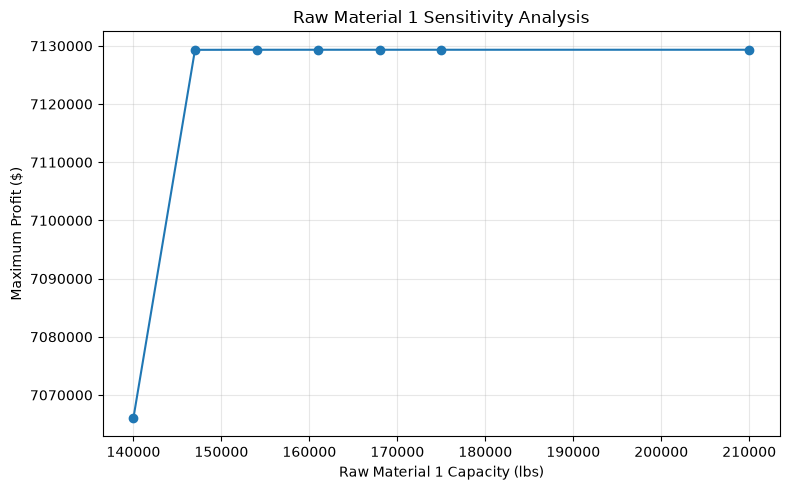

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    rm1_sensitivity_df["RM1 Capacity"],
    rm1_sensitivity_df["Maximum Profit"],
    marker="o"
)

plt.xlabel("Raw Material 1 Capacity (lbs)")
plt.ylabel("Maximum Profit ($)")
plt.title("Raw Material 1 Sensitivity Analysis")

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Figure A2: Profit Change Relative to Baseline

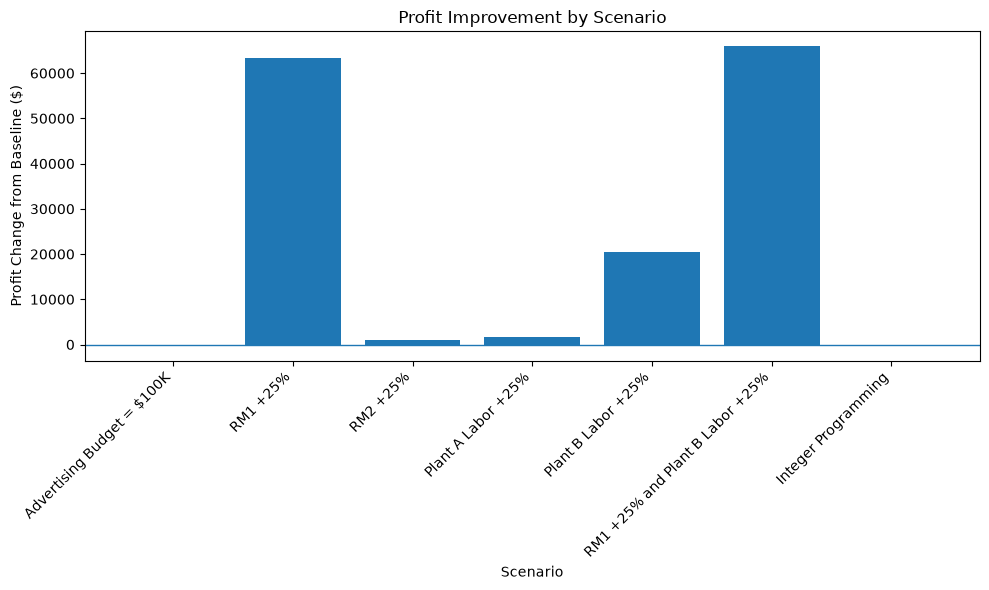

In [46]:
scenario_plot_df = overall_comparison[
    overall_comparison["Scenario"] != "Baseline"
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    scenario_plot_df["Scenario"],
    scenario_plot_df["Profit Change from Baseline"]
)

plt.xlabel("Scenario")
plt.ylabel("Profit Change from Baseline ($)")
plt.title("Profit Improvement by Scenario")

plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Figure A3: Regular and Overtime Labor Usage by Plant and Period

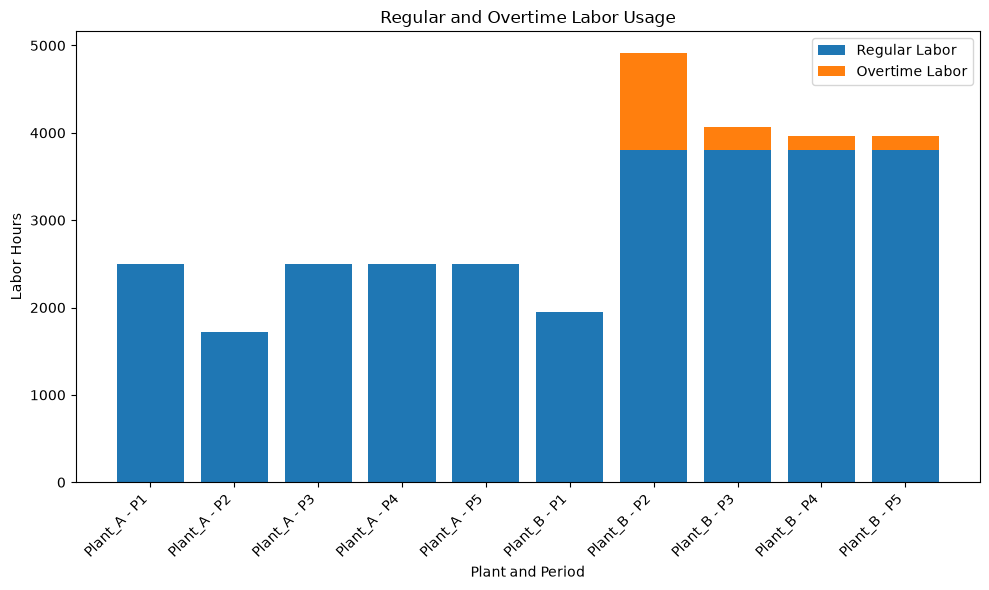

In [47]:
labor_plot_df = labor_results.copy()

x_labels = (
    labor_plot_df["Plant"]
    + " - P"
    + labor_plot_df["Period"].astype(str)
)

x = range(len(labor_plot_df))

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    labor_plot_df["Regular Labor"],
    label="Regular Labor"
)

plt.bar(
    x,
    labor_plot_df["Overtime Labor"],
    bottom=labor_plot_df["Regular Labor"],
    label="Overtime Labor"
)

plt.xticks(x, x_labels, rotation=45, ha="right")

plt.xlabel("Plant and Period")
plt.ylabel("Labor Hours")
plt.title("Regular and Overtime Labor Usage")

plt.legend()

plt.tight_layout()
plt.show()

### Figure A4: Raw Material Capacity Utilization

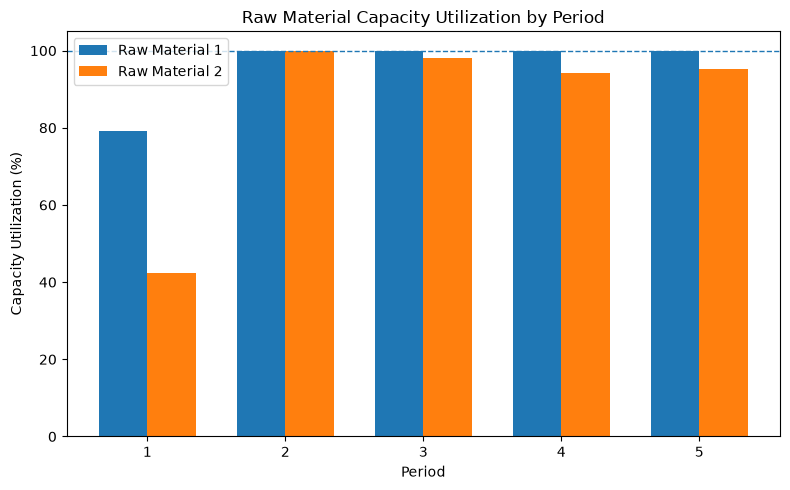

In [48]:
raw_material_plot_df = raw_material_results.copy()

raw_material_plot_df["RM1 Utilization (%)"] = (
    raw_material_plot_df["Raw Material 1 Used"]
    / raw_material_plot_df["Raw Material 1 Capacity"]
    * 100
)

raw_material_plot_df["RM2 Utilization (%)"] = (
    raw_material_plot_df["Raw Material 2 Used"]
    / raw_material_plot_df["Raw Material 2 Capacity"]
    * 100
)

x = range(len(raw_material_plot_df))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width / 2 for i in x],
    raw_material_plot_df["RM1 Utilization (%)"],
    width=width,
    label="Raw Material 1"
)

plt.bar(
    [i + width / 2 for i in x],
    raw_material_plot_df["RM2 Utilization (%)"],
    width=width,
    label="Raw Material 2"
)

plt.xticks(x, raw_material_plot_df["Period"])

plt.xlabel("Period")
plt.ylabel("Capacity Utilization (%)")
plt.title("Raw Material Capacity Utilization by Period")

plt.axhline(100, linestyle="--", linewidth=1)
plt.legend()

plt.tight_layout()
plt.show()

### Table A5: Integer Production Plan

In [49]:
integer_production_results = []

for product in products:
    for plant in plants:
        for period in periods:
            integer_production_results.append({
                "Product": product,
                "Plant": plant,
                "Period": period,
                "Integer Production": integer_production[
                    (product, plant, period)
                ].varValue
            })

integer_production_df = pd.DataFrame(integer_production_results)

integer_production_df

,Product,Plant,Period,Integer Production
0,Widget,Plant_A,1,61
1,Widget,Plant_A,2,25
2,Widget,Plant_A,3,72
3,Widget,Plant_A,4,79
4,Widget,Plant_A,5,84
5,Widget,Plant_B,1,9
6,Widget,Plant_B,2,100
7,Widget,Plant_B,3,114
8,Widget,Plant_B,4,113
9,Widget,Plant_B,5,113


### Table A6: LP and Integer Model Comparison

In [50]:
lp_integer_comparison = pd.DataFrame({
    "Model": [
        "Continuous LP",
        "Integer Production Model"
    ],
    "Maximum Profit": [
        baseline_profit,
        integer_profit
    ],
    "Difference from Baseline": [
        0,
        integer_profit - baseline_profit
    ]
})

lp_integer_comparison.round(1)

,Model,Maximum Profit,Difference from Baseline
0,Continuous LP,7066036.8,0.0
1,Integer Production Model,7065782.9,-253.9


# Final Recommendations

Based on the scenario and sensitivity results, NU Industries should prioritize increasing the availability of Raw Material 1 instead of increasing the advertising budget. An increase of about 5 percent provides almost all of the available profit improvement before other constraints start to limit the model. If NU Industries decides to increase labor capacity, Plant B should be prioritized because increasing its regular labor capacity has a much larger impact on profit than increasing capacity at Plant A.

The baseline solution also shows that inventory can help reduce production pressure in later periods. For example, producing some Gadgets earlier allows them to be carried into the next period when needed. At Plant B, the Period 2 labor cost plus one period of inventory holding cost is about $2.88 less per Gadget than producing the same Gadget in Period 3.

## Model Limitations and Future Work

The model assumes that contract demand, selling prices, production requirements, raw material availability, and advertising response are known in advanced. It also assumes that advertising creates a fixed amount of demand in the next period and that overtime labor is readily available. In addition, the model does not allow shortages or backorders since all demand must be satisfied.

Future work could look at more realistic conditions, like changes in demand or raw material availability, limits on overtime, additional suppliers, different advertising responses, more production capacity, or changes in inventory capacity. This would allow the model to better represent real-world operating conditions.

## Conclusion

The baseline linear programming model produces a maximum profit of about $7.07 million while meeting the overall demand and operating requirements. Validation results also show that the inventory, labor, raw material, advertising, and demand constraints are functioning properly within the numerical solver tolerance.

The scenario and sensitivity analyses highlight Raw Material 1 as the primary resource limiting additional profit. Increasing its availability by about 5 percent provides the majority of the available profit improvement before other constraints start to become limiting. Increasing regular labor capacity at Plant B also offers an additional benefit, meanwhile an increase in advertising budget does not improve profit. The integer programming model reduces profit by approximately only $253.9. This shows that requiring whole units for production minimally affects the overall results.